## Decision trees and random forests for obesity habits classification 

This paper contains data for the estimation of obesity levels in people from the countries of Mexico,
Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition as
mentioned by [1].

Data was collected using a web platform with a survey (see Table 1) where anon-
ymous users answered each question, then the information was processed obtaining 17 attributes and
2111 records, after a balancing process described in Figs. 1 and 2.

### The attributes related with eating habits are: 

- Frequent consumption of high caloric food (FAVC),
- Frequency of consumption of vegetables (FCVC), 
- Number of main meals (NCP), 
- Consumption of food between meals (CAEC),
- Consumption of water daily (CH20),
- Consumption of alcohol (CALC). 

### The attributes related with the physical condition are: 

- Calories consumption monitoring (SCC), 
- Physical activity frequency (FAF), 
- Time using technology devices (TUE),
- Transportation used (MTRANS)

### other variables obtained were: 
- Gender, 
- Age,
- Height 
- Weight.

Finally, all data was labeled and the class variable NObesity was created with the
values of: 
- Insuf cient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I,
Obesity Type II and Obesity Type III, based on Equation (1) and information from WHO and Mexican
Normativity.

 The data contains numerical data and continous data, so it can be used for analysis based
on algorithms of classi cation, prediction, segmentation and association. Data is available in CSV
format and ARFF format to be used with the Weka tool.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy
import seaborn as sns

In [2]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
df2 = df.copy()

In [3]:
df2

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [4]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [5]:
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [6]:
n, p =df.shape
n, p

(2111, 17)

In [7]:
## Rajout de la colonne IMC_index puis mise à jour des classes de poids

df["IMC_index"] = df["Weight"]/(df["Height"]**2)

def categorize_weight(row):
    weight_index = row['Weight'] / (row['Height'] ** 2)
    if weight_index < 18.5:
        return 'Underweight'
    elif 18.5 <= weight_index < 25:
        return 'Normal'
    elif 25 <= weight_index < 30:
        return 'Overweight'
    elif 30 <= weight_index < 35:
        return 'Obesity I'
    elif 35 <= weight_index < 40:
        return 'Obesity II'
    else:
        return 'Obesity III'
    
df["Weight_class"] = df.apply(categorize_weight, axis=1)
weight_order = ["Underweight", "Normal", "Overweight", "Obesity I", "Obesity II", "Obesity III"]
df["Weight_class"] = pd.Categorical(df["Weight_class"], categories=weight_order, ordered=True)

## Train / test separation

In [8]:
def split_train_test(data : pd.DataFrame, test_ratio, y):
    shuffle = np.random.permutation(n)
    separator = int(test_ratio*n)
    tr_indices = shuffle[:separator]
    te_indices = shuffle[separator:]

    return data.iloc[tr_indices], data.iloc[te_indices], y[tr_indices], y[te_indices]

In [9]:
tr_data, te_data, y_tr, y_te = split_train_test(df, 0.8, df["Weight_class"])

In [10]:
tr_data.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,IMC_index,Weight_class
300,Male,26.000000,1.700000,70.000000,no,yes,2.000000,3.000000,Sometimes,yes,1.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,24.221453,Normal
1730,Male,30.595632,1.910672,129.232708,yes,yes,2.497548,3.000000,Sometimes,no,1.362583,no,1.144076,0.173232,Sometimes,Public_Transportation,Obesity_Type_II,35.399748,Obesity II
2083,Female,24.469756,1.663341,113.077187,yes,yes,3.000000,3.000000,Sometimes,no,2.632224,no,0.300964,0.269560,Sometimes,Public_Transportation,Obesity_Type_III,40.870732,Obesity III
1151,Male,25.457630,1.837399,95.952027,yes,yes,1.122127,2.865657,Sometimes,no,2.000000,no,1.287750,1.944177,Sometimes,Public_Transportation,Overweight_Level_II,28.421514,Overweight
1085,Female,28.824194,1.700000,78.000000,yes,yes,3.000000,3.000000,Sometimes,no,2.147074,no,1.416076,1.000000,Frequently,Automobile,Overweight_Level_II,26.989619,Overweight
829,Female,21.198217,1.743841,78.880360,yes,yes,2.510583,1.000000,Sometimes,no,2.000000,no,2.119682,0.000000,Sometimes,Public_Transportation,Overweight_Level_I,25.939113,Overweight
932,Male,22.828435,1.710415,75.142858,yes,yes,2.786008,3.000000,Sometimes,no,2.526193,no,0.925118,2.000000,Sometimes,Public_Transportation,Overweight_Level_I,25.685304,Overweight
643,Male,19.962470,1.756338,54.982340,yes,yes,2.277436,3.502604,Sometimes,no,2.891713,no,1.696294,1.894902,no,Public_Transportation,Insufficient_Weight,17.824076,Underweight
213,Male,21.000000,1.800000,62.000000,yes,yes,3.000000,3.000000,Sometimes,no,2.000000,no,1.000000,0.000000,no,Public_Transportation,Normal_Weight,19.135802,Normal
1168,Male,22.649792,1.685045,81.022119,yes,yes,2.000000,2.756622,Sometimes,no,1.606076,no,0.432973,1.749586,no,Public_Transportation,Overweight_Level_II,28.535178,Overweight


## Categorical vs numerical variables

In [11]:
numerical_variables = ["Age", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
categorical_variables = ["Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]
labels = list(df["Weight_class"].unique())

In [12]:
from sklearn.preprocessing import OrdinalEncoder


In [13]:
df[categorical_variables]

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation
3,Male,no,no,Sometimes,no,no,Frequently,Walking
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation
...,...,...,...,...,...,...,...,...
2106,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation
2107,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation
2108,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation
2109,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation


In [15]:
labels

['Normal',
 'Overweight',
 'Obesity I',
 'Underweight',
 'Obesity II',
 'Obesity III']

## Pipeline computation

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [17]:
tr_data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,IMC_index,Weight_class
300,Male,26.000000,1.700000,70.000000,no,yes,2.000000,3.000000,Sometimes,yes,1.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,24.221453,Normal
1730,Male,30.595632,1.910672,129.232708,yes,yes,2.497548,3.000000,Sometimes,no,1.362583,no,1.144076,0.173232,Sometimes,Public_Transportation,Obesity_Type_II,35.399748,Obesity II
2083,Female,24.469756,1.663341,113.077187,yes,yes,3.000000,3.000000,Sometimes,no,2.632224,no,0.300964,0.269560,Sometimes,Public_Transportation,Obesity_Type_III,40.870732,Obesity III
1151,Male,25.457630,1.837399,95.952027,yes,yes,1.122127,2.865657,Sometimes,no,2.000000,no,1.287750,1.944177,Sometimes,Public_Transportation,Overweight_Level_II,28.421514,Overweight
1085,Female,28.824194,1.700000,78.000000,yes,yes,3.000000,3.000000,Sometimes,no,2.147074,no,1.416076,1.000000,Frequently,Automobile,Overweight_Level_II,26.989619,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,Female,43.726081,1.592316,77.001030,yes,yes,2.000000,3.000000,Sometimes,no,2.806922,no,0.000000,0.000000,Sometimes,Automobile,Obesity_Type_I,30.369526,Obesity I
843,Male,21.652229,1.700181,75.057177,yes,yes,2.086093,3.546352,Sometimes,no,2.081121,no,1.993666,0.673835,Sometimes,Public_Transportation,Overweight_Level_I,25.965812,Overweight
1880,Female,21.566815,1.748533,133.946080,yes,yes,3.000000,3.000000,Sometimes,no,2.833566,no,1.413239,0.862724,Sometimes,Public_Transportation,Obesity_Type_III,43.810917,Obesity III
297,Male,26.000000,1.740000,80.000000,no,no,2.000000,3.000000,Sometimes,no,2.000000,no,2.000000,0.000000,no,Automobile,Overweight_Level_I,26.423570,Overweight


In [18]:
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy='median')),
                        ("std_scaler", StandardScaler())])

In [19]:
full_pipeline = ColumnTransformer([("num", num_pipeline, numerical_variables),
                                   ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_variables)], verbose_feature_names_out= False)
full_pipeline.set_output(transform="pandas")
tr_data = full_pipeline.fit_transform(tr_data)
te_data = full_pipeline.transform(te_data)

## Training a first model

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=10)
dt.fit(tr_data, y_tr)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = dt.predict(te_data)

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [23]:
cm = confusion_matrix(y_te, y_pred, labels= labels)

In [24]:
display = ConfusionMatrixDisplay(cm, display_labels=labels)

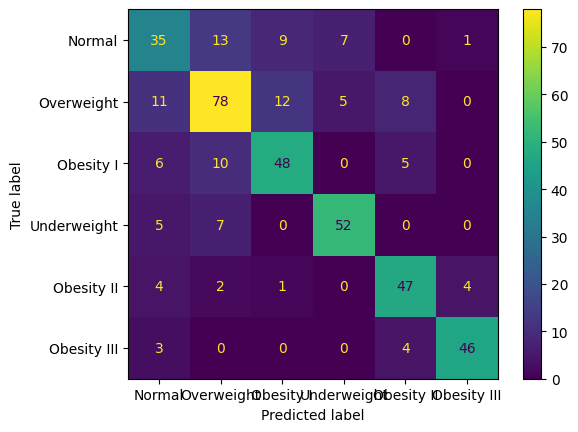

In [25]:
display.plot()

## Defining the cross-validation score

In [26]:
from sklearn.model_selection import cross_val_score

cross_data = cross_val_score(DecisionTreeClassifier(), tr_data, y_tr, cv = 10)

## Optimization of hyperparameters with cross-validation score

In [27]:
depths = np.arange(10,31,2)
leaf_size = np.arange(3,16,2)

In [28]:
depths.shape

(11,)

In [29]:
def parameter_optim_tree(depths, leaf_size, df, n_iterations = 10):
    moyenne = []
    std = []
    config = []

    for n in range(n_iterations):
        results = np.zeros(4)
        for di in range(depths.shape[0]):
            for leaf in range(leaf_size.shape[0]):
                X_tr, X_te, y_tr, y_te = split_train_test(df, 0.8, df["Weight_class"])
                X_tr = full_pipeline.fit_transform(X_tr)
                tree = DecisionTreeClassifier(criterion='entropy', splitter = "best", max_depth=depths[di], min_samples_leaf=leaf_size[leaf])
                val_score = cross_val_score(tree, X_tr, y_tr, cv = 10)
                score = val_score.mean()
                var = val_score.std()
                if score > results[0]:
                    results[0] = score
                    results[1] = depths[di]
                    results[2] = leaf_size[leaf]
                    results[3] = var
        
        score = results[0]
        ecart = results[3]
        moyenne.append(score)
        std.append(ecart)
        config.append((results[1], results[2]))

    MEAN = np.mean(moyenne)
    STD = np.std(std)
    
    return MEAN, STD, config


In [30]:
#parameter_optim_tree(depths, leaf_size, df)

## Plotting the ROC curve for the decision tree

In [31]:
from sklearn.preprocessing import LabelBinarizer

In [32]:
label_binarizer = LabelBinarizer().fit(y_tr)
y_one_hot_test = label_binarizer.transform(y_te)
y_one_hot_test.shape

(423, 6)

In [33]:
print(label_binarizer.transform(["Underweight"]), 
label_binarizer.transform(["Normal"]), 
label_binarizer.transform(["Overweight"]), 
label_binarizer.transform(["Obesity I"]))

[[0 0 0 0 0 1]] [[1 0 0 0 0 0]] [[0 0 0 0 1 0]] [[0 1 0 0 0 0]]


In [34]:
class_of_interest = "Underweight"
class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)[0]
class_id

np.int64(5)

In [35]:
from sklearn.metrics import RocCurveDisplay

In [36]:
y_pred_probs = dt.predict_proba(te_data)

In [37]:
y_pred_probs

array([[0.1       , 0.        , 0.        , 0.        , 0.9       ,
        0.        ],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        ],
       ...,
       [0.77777778, 0.        , 0.        , 0.        , 0.22222222,
        0.        ],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        ]], shape=(423, 6))

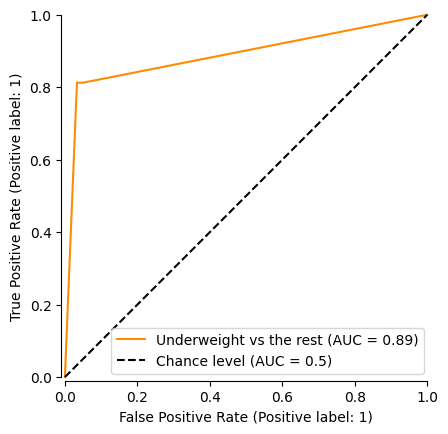

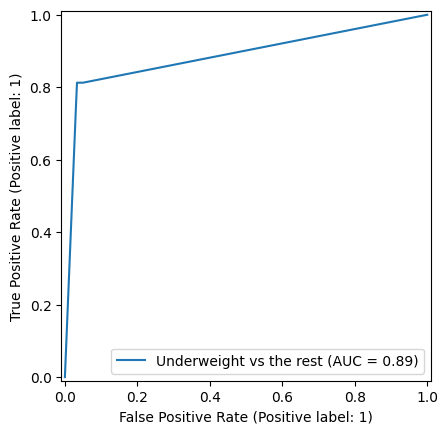

In [38]:
display = RocCurveDisplay.from_predictions(y_one_hot_test[:, class_id], y_pred_probs[:, class_id], name=f"{class_of_interest} vs the rest",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
display.plot()

## RANDOM FORESTS

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
n_estimators = np.arange(1, 80, 2)
depth = 20
leaf_size = 3

In [ ]:
def parameter_optim_forest(depth, leaf_size, df, n_estimators, n_iterations=10):
    moyenne = []
    variance = []
    NUM_ESTIMATOR = []
    memory = []

    for n in range(n_iterations):
        results = np.zeros(4)
        for n_estimator in range(n_estimators.shape[0]):
            X_tr, X_te, y_tr, y_te = split_train_test(df, 0.8, df["Weight_class"])
            X_tr = full_pipeline.fit_transform(X_tr)
            rf = RandomForestClassifier(criterion='entropy', max_depth=depth, min_samples_leaf=leaf_size, n_estimators=n_estimators[n_estimator])
            val_score = cross_val_score(rf, X_tr, y_tr, cv = 10)
            score = val_score.mean()
            var = val_score.std()
            if score > results[0]:
                results[0] = score
                results[1] = n_estimators[n_estimator]
                results[2] = var
            memory.append(score)

        
        score = results[0]
        moyenne.append(score)
        variance.append(var)
        NUM_ESTIMATOR.append(results[1])

    MEAN = np.mean(moyenne)
    STD = np.mean(variance)
    
    return MEAN, STD, NUM_ESTIMATOR, memory, variance

In [ ]:
MEAN, STD, NUM_ESTIMATOR, memory, variance = parameter_optim_forest(depth, leaf_size, df, n_estimators, n_iterations=5)



In [44]:
memory = np.array(memory).reshape(5, len(n_estimators)) # (10, 40)
mean_curve = memory.mean(axis = 0)
std_curve = memory.std(axis = 0) # dispersion entre les 5 répétitions

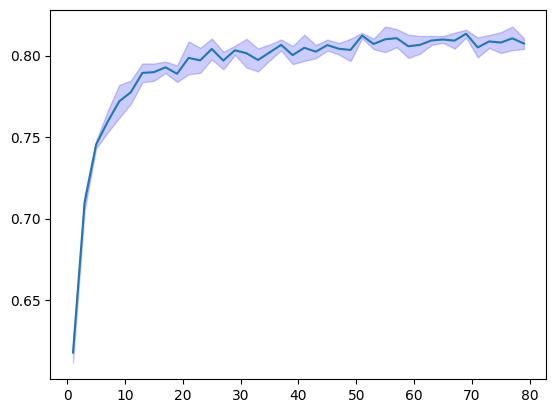

In [53]:
N = np.arange(40)
plt.plot(n_estimators, mean_curve)
plt.fill_between(n_estimators, mean_curve - std_curve, mean_curve + std_curve, color = 'blue', alpha = .2)

## Feature importance with Random forests

## Bagging implementation

## Implémentation de XGBoost

In [ ]:
from xgboost import XGBClassifier
import xgboost as xgb

In [ ]:
dtrain = xgb.DMatrix(tr_data, label = y_tr.cat.codes)
dtest = xgb.DMatrix(te_data, label = y_te.cat.codes)

In [ ]:
param = {
    'max_depth': 3,  # the maximum depth of each tree
    'eta': 0.3,  # Learning rate, the training step for each iteration
    'objective': 'multi:softprob',  # Evaluation metrics for training
    'num_class': 6, # Number of classes in this dataset
    'eval_metric': 'mlogloss' # Evaluation metrics for validation data
}
num_round = 20  # the number of training iterations

In [ ]:
model = xgb.train(param, dtrain, num_round)
preds = model.predict(dtest)
predictions = np.asarray([np.argmax(line) for line in preds])

acc_xgb = (predictions == y_te.cat.codes).sum().astype(float) / len(predictions)*100
print("XGBoost's prediction accuracy is: %3.2f" % (acc_xgb))

XGBoost's prediction accuracy is: 71.87


In [ ]:
importances = (pd.Series(model.get_score(importance_type="gain"), name="Importance")
                 .reindex(tr_data.columns, fill_value=0)   # remet les variables absentes à 0
                 .sort_values(ascending=False))
importances

FCVC                              17.260483
family_history_with_overweight    16.807096
Gender                            10.589436
Age                               10.527338
TUE                               10.377651
CAEC                               8.915753
CH2O                               8.875685
NCP                                7.404611
MTRANS                             5.945145
CALC                               5.811130
FAF                                4.394792
SCC                                4.316308
FAVC                               3.714481
SMOKE                              3.699447
Name: Importance, dtype: float64

In [ ]:
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(tr_data, y_tr)
preds = rfc.predict(te_data)
acc_rfc = (preds == y_te).sum().astype(float) / len(preds)*100
print("Scikit-Learn's Random Forest Classifier's prediction accuracy is: %3.2f" % (acc_rfc))

Scikit-Learn's Random Forest Classifier's prediction accuracy is: 83.45
